## imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MultipleLocator
import matplotlib as mpl
from scipy.optimize import curve_fit
import matplotlib.patheffects as pe
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from pathlib import Path

## plot style

In [2]:
plt.style.use('./include/sf.mplstyle')
plot_style = {'notebook':'./include/notebook.mplstyle','aps':'./include/sf.mplstyle'}
plt.style.reload_library()
plt.style.use(plot_style['aps'])
figsize = plt.rcParams['figure.figsize'] 

style_file = plot_style['aps']
plt.rcParams['figure.constrained_layout.use'] = True

try:
    get_ipython().run_line_magic("config", "InlineBackend.figure_format = 'svg'")
except NameError:
    pass

def marker_style(color):
    """Common marker-edge and marker-face settings used in the figure."""
    return {
        "color": color,
        "markeredgecolor": color,
        "markerfacecolor": "none", 
        "markersize": 4, 
    }

_figsize = plt.rcParams['figure.figsize'] 
_figsize=[_figsize[0]+0.1,_figsize[0]+0.55]

COLORS = ["#524582", "#367bc3", "#FFFFFF", "#38bfa7", "#8fe182"]
RDM_CMAP = LinearSegmentedColormap.from_list("rdm_diverging", COLORS, N=500)
GUIDE_STYLE = {"color": "#ff0035", "linestyle": "--", "linewidth": 1.0}

import functions

In [3]:
from LL_definitions import lambda_from_K, gamma_from_K, K_from_V, lambda_from_V, gamma_from_V
from two_rdm import density_density_limit_scalar, two_rdm_fixed_delta_R, wick_residual_direct, interaction_correction_direct, two_rdm, fixed_delta_R_coordinates, analytic_g2
from one_rdm import one_rdm
from coherences import delta_rho_cdw
from structurefactor import structure_factor, enforce_pair_sum_rule
from energy import E_sum
from load import load_obdm, load_tbdm, load_g2, load_energies
from chord import points_with_distance

# Generate Figures for "The two particle density matrix of a Luttinger Liquid"

### Figure 02
Dependence of the two interaction dependent exponents in the correlation function, $\gamma^2$ and $\lambda$, on the Luttinger parameter $K$. $\gamma^2$ is strictly positive, while $\lambda$, the new exponent in this work, can attain negative values.

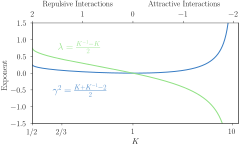

In [4]:
vJvals = np.linspace(2, -2, 1000)
with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
    γ2_values = gamma_from_V(vJvals)
    λ_values = lambda_from_V(vJvals)

f, axtop = plt.subplots()
# Plot the curves with reversed x-values and original y-values
axtop.plot(vJvals[::-1], γ2_values[::-1],color='#367bc3')
axtop.plot(vJvals[::-1], λ_values[::-1], color='#8fe182')

# Set labels and limits
axtop.set_ylabel('Exponent') 
axtop.set_ylim(-1.5, 1.5)
axtop.set_xlim(2, -2.1)
axtop.tick_params(axis='x', which='both', bottom=False, top=True, labelbottom=False, labeltop=True)

axbottom = axtop.twiny()

# Set limits for the bottom axis to match the top axis
axbottom.set_xlim(axtop.get_xlim())

# Add custom tick labels to the bottom x-axis
bottom_ticks = [0, -1.975,  1.4142, 2]
bottom_labels = ['1', '10', '2/3', '1/2']
axtop.set_xticks(bottom_ticks)
axtop.set_xticklabels(bottom_labels)
axtop.set_xlabel(r'$K$')
axbottom.spines['top'].set_visible(False)

axtop.text(1.5, 0.7, r'$\lambda=\frac{K^{-1}-K}{2}$', color='#8fe182', fontsize=10)
axtop.text(1.6, -0.6, r'$\gamma^2=\frac{K+K^{-1}-2}{2}$', color='#367bc3', fontsize=10)
axtop.text(-0.3, 2,'Attractive Interactions', fontsize=8)
axtop.text(1.8, 2,'Repulsive Interactions', fontsize=8)
plt.savefig('../figures/Fig_02_Exponents.pdf')
plt.savefig('../figures/Fig_02_Exponents.svg')
plt.show()

### Figure 03
The density-density correlation function $g_2(r)$ at fixed $L=50$ for different values of the Luttinger parameter $K$.

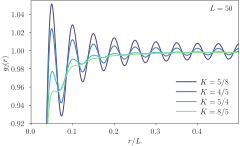

In [5]:
colors=['#524582','#367bc3','#38bfa7','#8fe182']
colors2=['#000000','#003472','#367bc3','#a5bae1']

vJs=[-1.5,-0.5,0.5,1.5]
ks=[.649, .861, 1.192, 2.173]
ks=[5/8, 4/5, 5/4, 8/5]
ks_labels = ['5/8', '4/5', '5/4', '8/5']
Ls=[20,40,50,64]
rho_0 = 1/2

for i,k in enumerate(ks):
    L=40
    diffs=np.linspace(.005,L/2,1000)
    density_density = [density_density_limit_scalar(d, L=L, epsilon=1, K=k, rho0=0.5)/rho_0**2 for d in diffs]
    plt.plot(diffs/L, density_density, label=rf'$K={ks_labels[i]}$',color=colors[i])

plt.xlabel(r'$r/L$')
plt.legend()

plt.ylim(0.92,1.055)


plt.ylabel(r'$g_2(r)$')
plt.text(.49,1.05,r'$L=50$', ha='right', va='top')
plt.tick_params(axis='both', which='major')
plt.xlim(0,.499)

plt.savefig('../figures/Fig_03_densitydensitynorm.pdf')
plt.savefig('../figures/Fig_03_densitydensitynorm.svg')

### Figure 04
The 2-RDM of the Luttinger model on a ring for attractive $K=8/5$, (top row) and repulsive $K=5/8$ (bottom row) at two fixed values of $\Delta R = L/5 + 1/2$ (left column) and $\Delta R = L/5$ (right column) where $L=40$. The particular values of $\Delta R$ are to suppress(enhance) the first oscillating fermionic term as indicated in the panel titles.  Red dashed lines denote the lines corresponding to the limits (hyperplanes) $x'_1\to x_1$, $x'_2\to x_2$, $x'_2\to x_1$, and $x'_1\to x_2$.

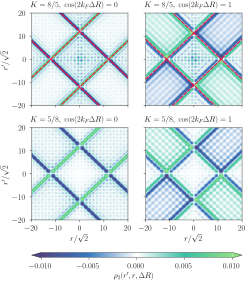

In [6]:
r_fixed_values = np.linspace(-L / np.sqrt(2), L / np.sqrt(2), 300)
rp_fixed_values = np.linspace(-L / np.sqrt(2), L / np.sqrt(2), 300)
RF, RPF = np.meshgrid(r_fixed_values, rp_fixed_values, indexing="xy")

delta_R_values = (L / 5 + 0.5, L / 5)
delta_R_labels = (r"L/5+1/2", r"L/5")

K_VALUES = (8 / 5, 5 / 8)
K_LABELS = (r"8/5", r"5/8")
EPSILON = 1.0
ETA = 0.0

delta_R_labels = (r"0", "1") 

_figsize = plt.rcParams['figure.figsize'] 
_figsize=[_figsize[0]+0.1,_figsize[0]+0.55]

fig, axes = plt.subplots(2, 2, figsize=_figsize, sharex=True, sharey=True, constrained_layout=True)

for i, (K, K_label) in enumerate(zip(K_VALUES, K_LABELS)):
    for j, (delta_R, delta_R_label) in enumerate(
        zip(delta_R_values, delta_R_labels)
    ):
        values = two_rdm_fixed_delta_R(
            RF, RPF, delta_R, EPSILON, K, L, ETA
        )
        ax = axes[i, j]
        image = ax.pcolormesh(
            RF / np.sqrt(2),
            RPF / np.sqrt(2),
            np.real(values),
            shading="auto",
            cmap=RDM_CMAP,
            vmin=-0.01,
            vmax=0.01,
            rasterized=True,
        )   
        ax.set_title(rf"$K={K_label},\;\cos(2k_F \Delta R)={delta_R_label}$", fontsize=8)

        ax.set_xlim(-20,20)
        ax.set_ylim(-20,20)
        if i == 1:
            ax.set_xlabel(r"$r/\sqrt{2}$")
        if j == 0:
            ax.set_ylabel(r"$r'/\sqrt{2}$")

        # Draw guides only in the top row to keep the lower panels readable.
        if i == 0:
            x_plot = r_fixed_values / np.sqrt(2)
            for y_values in (
                2 * delta_R - r_fixed_values,
                2 * delta_R + r_fixed_values,
                -2 * delta_R - r_fixed_values,
                -2 * delta_R + r_fixed_values,
            ):
                ax.plot(x_plot, y_values / np.sqrt(2), **GUIDE_STYLE)

colorbar = fig.colorbar(
    image,
    ax=axes.ravel().tolist(),
    orientation="horizontal",
    pad=0.04,
    aspect=40,
    extend="both",
)
colorbar.set_label(r"$\rho_2(r',r,\Delta R)$")

plt.savefig('../figures/Fig_04_fixed_pair_center_separation.pdf')
plt.savefig('../figures/Fig_04_fixed_pair_center_separation.svg') 

### Figure 05
The second cumulant of the Luttinger model for spinless fermions on a ring for attractive $K=8/5$, (top row) and repulsive $K=5/8$ (bottom row) at two fixed values of $d = x_1'-x_1 = L/10 + 1/2$ (left column) and $d = L/4+1/2$ (right column) where $L=40$.

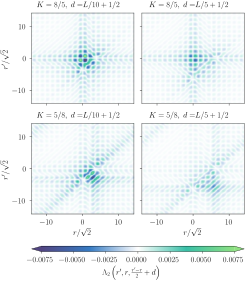

In [7]:
r_values = np.linspace(-L / 2, L / 2, 300)
rp_values = np.linspace(-L / 2, L / 2, 300)
R, RP = np.meshgrid(r_values, rp_values, indexing="xy")

K_VALUES = (8 / 5, 5 / 8)
K_LABELS = (r"8/5", r"5/8")
EPSILON = 1.0
ETA = 0.0

d_values = (L / 10 + 0.5, L / 5 + 0.5)

d_labels = (r"$\scriptstyle \frac{L}{10}+\frac{1}{2}$", r"$\scriptstyle \frac{L}{5}+\frac{1}{2}$")
d_labels = (r"$ {L}/{10}+{1}/{2}$", r"${L}/{5}+{1}/{2}$") 

_figsize = plt.rcParams['figure.figsize'] 
_figsize=[_figsize[0]+0.1,_figsize[0]+0.55]

fig, axes = plt.subplots(2, 2, figsize=_figsize, sharex=True, sharey=True, constrained_layout=True)
wick_maps = []

for i, (K, K_label) in enumerate(zip(K_VALUES, K_LABELS)):
    for j, (d, d_label) in enumerate(zip(d_values, d_labels)):
        values = wick_residual_direct(R, RP, d, EPSILON, K, L, ETA)
        wick_maps.append(values)
        ax = axes[i, j]
        image = ax.pcolormesh(R / np.sqrt(2),RP / np.sqrt(2), np.real(values),shading="auto",
                              cmap=RDM_CMAP,vmin=-0.0075,vmax=0.0075,rasterized=True)
        ax.set_title(rf"$K={K_label},\;d=$"+d_label, fontsize=8)
        if i == 1:
            ax.set_xlabel(r"$r/\sqrt{2}$")
        if j == 0:
            ax.set_ylabel(r"$r'/\sqrt{2}$") 

ticks = np.arange(-0.0075, 0.0075 + 0.0025, 0.0025)
colorbar = fig.colorbar(
    image,
    ax=axes.ravel().tolist(),
    orientation="horizontal",
    pad=0.04,
    aspect=40,
    extend="both",
    ticks=ticks,
)
colorbar.set_label(
    r"$\Lambda_2\left(r',r,\frac{r'-r}{2}+d\right)$" #\rho_2-\mathcal{A}(\rho_1\rho_1)$"
)

plt.savefig('../figures/Fig_05_Wick_residual.pdf')
plt.savefig('../figures/Fig_05_Wick_residual.svg')  

### Figure 06
The interaction change defined as the difference between the interacting and free fermion 2-RDM for attractive $K=8/5$, (top row) and repulsive $K=5/8$ (bottom row) at two fixed values of $d = x_1'-x_1 = L/10 + 1/2$ (left column) and $d = L/5+1/2$. Red dashed lines indicate $x_1'=x_2$, $x_2'=x_1$, and $x_2'=x_2$.

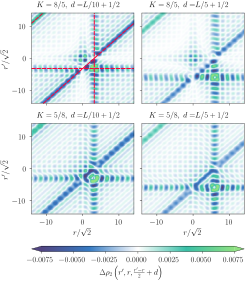

In [8]:
K_VALUES = (8 / 5, 5 / 8)
K_LABELS = (r"8/5", r"5/8")
EPSILON = 1.0
ETA = 0.0

d_values = (L / 10 + 0.5, L / 5 + 0.5)
d_labels = (r"$\scriptstyle \frac{L}{10}+\frac{1}{2}$", r"$\scriptstyle \frac{L}{4}+\frac{1}{2}$")
d_labels = (r"$ {L}/{10}+{1}/{2}$", r"${L}/{5}+{1}/{2}$") 

_figsize = plt.rcParams['figure.figsize'] 
_figsize=[_figsize[0]+0.1,_figsize[0]+0.55]

fig, axes = plt.subplots(2, 2, figsize=_figsize, sharex=True, sharey=True, constrained_layout=True)
interaction_maps = []

for i, (K, K_label) in enumerate(zip(K_VALUES, K_LABELS)):
    for j, (d, d_label) in enumerate(zip(d_values, d_labels)):
        values = interaction_correction_direct(R, RP, d, EPSILON, K, L, ETA)
        interaction_maps.append(values)
        ax = axes[i, j]
        image = ax.pcolormesh(
            R / np.sqrt(2),
            RP / np.sqrt(2),
            np.real(values),
            shading="auto",
            cmap=RDM_CMAP,
            vmin=-0.0075,
            vmax=0.0075,
            rasterized=True,
        )
        ax.set_title(rf"$K={K_label},\;d=$"+d_label, fontsize=8)
        if i == 1:
            ax.set_xlabel(r"$r/\sqrt{2}$")
        if j == 0:
            ax.set_ylabel(r"$r'/\sqrt{2}$")

# Geometric guides for d=L/10+1/2 in the upper-left panel.
ax = axes[0, 0]
d = d_values[0]
ax.axvline(d / np.sqrt(2), **GUIDE_STYLE)
ax.axhline(-d / np.sqrt(2), **GUIDE_STYLE)
ax.plot(
    r_values / np.sqrt(2), (r_values - d) / np.sqrt(2), **GUIDE_STYLE,
)
ax.plot(
    r_values / np.sqrt(2),  (r_values - d + L) / np.sqrt(2), **GUIDE_STYLE,
)
ax.set_xlim(-L / (2 * np.sqrt(2)), L / (2 * np.sqrt(2)))
ax.set_ylim(-L / (2 * np.sqrt(2)), L / (2 * np.sqrt(2)))

ticks = np.arange(-0.0075, 0.0075 + 0.0025, 0.0025)

colorbar = fig.colorbar(
    image,
    ax=axes.ravel().tolist(),
    orientation="horizontal",
    pad=0.04,
    aspect=40,
    extend="both",
    ticks=ticks,
)
colorbar.ax.xaxis.set_major_locator(MultipleLocator(0.0025))
colorbar.set_label(r"$\Delta \rho_2\left(r',r,\frac{r'-r}{2}+d\right)$")
colorbar.update_ticks()

plt.savefig('../figures/Fig_06_2RDM_interaction_correction.pdf')
plt.savefig('../figures/Fig_06_2RDM_interaction_correction.svg')   

### Figure 07
Orbital character of the CDW from the unnormalized  background-subtracted coherence $\delta\rho(\xi)=\rho(\xi)+\rho_0\rho_1(\xi)$, Eq.\eqref{eq:rho_CDW}, at $L=50$ for several repulsive $K$. Subtracting the single-particle background $-\rho_0\rho_1(\xi)$ [1-RDM, Eq.\eqref{Eq:OBDMLL}] isolates the form factor $\varphi(\xi)$, the dominant eigenvector of the particle--hole block of $\rho_2$ at $Q=2k_F$. The residual is even in $\xi$ and peaked at $\xi=0$ with no node, identifying the $J$-$V$ order as a site-centred ($s$-wave) CDW.

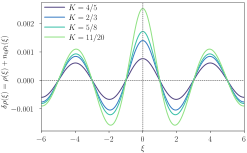

In [9]:
L_CDW = 50.0
XI_MAX = 6.0 

N_XI = 1001
xi = np.linspace(-XI_MAX, XI_MAX, N_XI)

parameter_sets = [(4/5, 1, r"$K=4/5$",colors[0]),(2/3, 1, r"$K=2/3$",colors[1]),
                  (5/8, 1, r"$K=5/8$",colors[2]), (11/20, 1, r"$K=11/20$",colors[3]),]
 
_figsize = plt.rcParams['figure.figsize'] 
_figsize=[_figsize[0]+0.1,_figsize[0]+0.55]

fig, ax = plt.subplots(figsize=(_figsize[0],_figsize[0]/1.6), constrained_layout=True)

for K, epsilon, label, col in parameter_sets:

    delta_rho = np.real(delta_rho_cdw(xi,epsilon=epsilon,K=K,L=L_CDW,)) 

    delta_rho[N_XI//2] = delta_rho[N_XI//2-1] 

    ax.plot(xi,delta_rho,label=label,color=col)

ax.axhline(0.0, linewidth=0.8, ls=":", color='grey')
ax.axvline(0.0, linewidth=0.8, linestyle=":",color='grey')

ax.set_xlim(-XI_MAX, XI_MAX)
ax.set_xlabel(r"$\xi$")
 
ax.set_ylabel(r"$\delta\rho(\xi) =\rho(\xi)+n_0\rho_1(\xi)$")

ax.legend(loc=(0,0.67))

plt.savefig('../figures/Fig_07_CDW_coherence_multiple_K.pdf')
plt.savefig('../figures/Fig_07_CDW_coherence_multiple_K.svg')    

### Figure 08
Heat map of $\rho_2(L/2+\nu, L/2, \mu, 0)$  in the attractive regime  $K > 1$. Positive (green) and negative (blue) lobes alternate across the nodal lines  $\mu = 0$ and $\nu = 0$, consistent with the antisymmetric $p$-wave character of the pair wavefunction.

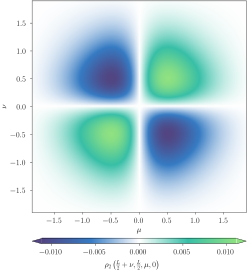

In [4]:
mu_values = np.arange(-2, 2.01, 0.01)
nu_values = np.arange(-2, 2.01, 0.01)

rho_values = np.zeros((len(mu_values), len(nu_values)))

# Compute values for rho
K = 8  
L = 40 
epsilon = 1  
for i, mu in enumerate(mu_values):
    for j, nu in enumerate(nu_values):
        rho_values[i, j] = np.real( two_rdm(L/2 + nu, L/2, mu, 0, epsilon, K, L, eta=0.0)) 


# Create the figure and axis
fig, ax = plt.subplots(figsize=(_figsize[0],_figsize[0]*1.1 ))
heatmap = ax.imshow(rho_values, extent=[-2, 2, -2, 2], origin='lower', cmap=RDM_CMAP, aspect='auto',rasterized=True)

# Add colorbar
cbar = fig.colorbar(heatmap, ax=ax,pad=.02, orientation="horizontal", aspect=40, extend="both")
cbar.set_label(r"$\rho_2\left(\frac{L}{2}+\nu, \frac{L}{2}, \mu, 0\right)$",labelpad=2)

# Set labels and title
ax.set_xlabel(r'$\mu$')
ax.set_ylabel(r'$\nu$')
ax.set_xlim(-1.9,1.9)
ax.set_ylim(-1.9,1.9)
# Save the figure
plt.savefig('../figures/Fig_08_Clustered_Solid_heatmap.pdf')
plt.savefig('../figures/Fig_08_Clustered_Solid_heatmap.svg')     

### Figure 10
We plot the one body reduced density matrix $\rho_1$ as a function of the relative coordinate $x-x'$ at fixed interaction $V/J=-0.5$ and system size $L=40$. From fitting DMRG results to our expression for the OBDM, we obtain a value for the interaction cutoff $\epsilon=0.81$. Blue dots represent the DMRG data points. On the right panel, we use the same value of $\epsilon$ for our computation of the 2-RDM as a function of the coordinate $x_1'$ and find similarly strong agreement with the numerical results.

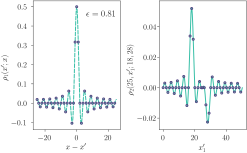

In [27]:
n_points = 1000

V = -0.5
with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
    K = K_from_V(V)
L = 50 

fig, axs_top = plt.subplots(1, 2, figsize=(_figsize[0],_figsize[0]/1.6), constrained_layout=True)

# 1RDM fit
fit_fun = lambda xi,ϵ : one_rdm(xp=xi, x=0.0, epsilon=ϵ, K=K, L=L, kF= np.pi / 2)

obdm = load_obdm(L=L,V=V)[:,L//2]

x = np.arange(-L//2,L//2)
x_fine = np.linspace(-L/2,L/2+0.005,n_points)
ϵ_fit = curve_fit(fit_fun,x,obdm,p0=0.84)[0][0]

ax = axs_top[0]
ax.plot(x,obdm,'o',label='drmg data',color=COLORS[0],mfc="none",ms=2,zorder=10)
ax.plot(x_fine,fit_fun(x_fine,ϵ_fit),label=f'fit $\epsilon={ϵ_fit:3.3f}$',linestyle='--',color=COLORS[3],zorder=2)
ax.text(26.3,0.45,f"$\epsilon={ϵ_fit:3.2f}$",fontsize=9,horizontalalignment="right")
ax.set_xlabel(r"$x-x'$")
ax.set_ylabel(r"$\rho_{1}(x'; x)$")


# 2RDM
x1 = L//2
x2 = np.linspace(0,L,n_points)
x3 = L//2  + 3
x4 = 18

trdm = np.real( two_rdm(x4, x3, x1, x2, epsilon=ϵ_fit, K=K, L=L, eta=0.0) ) 
full_TBDM = load_tbdm(L=L,V=V)
trdm_dmrg = [ full_TBDM[x3,x4,i,x1] for i in range(L)] 
  
ax = axs_top[1]
ax.plot(trdm_dmrg,'o',label='drmg data',color=COLORS[0],mfc="none",ms=2,zorder=10)
ax.plot(x2,trdm,label=f'fit $\epsilon={ϵ_fit:3.3f}$',color=COLORS[3],zorder=2) 
ax.set_xlabel(r"$x_1'$")
ax.set_ylabel(r"$\rho_{2}(25,x_1';18,28)$")
ax.set_ylim(np.min(trdm_dmrg)-0.005,np.max(trdm_dmrg)+0.005)
ax.tick_params(axis='y', which='major', pad=-1)

ax.set_yticks([-0.02,0.0,0.02,0.04])

plt.show()
fig.savefig("../figures/Fig_10_onevstwordm.pdf")
fig.savefig("../figures/Fig_10_onevstwordm.svg")

### Figure 11
Panel (a) shows a heat map of the full correlation function $\rho_2(L/2-4,x_1',L/20,x_1)$ with two fixed coordinates for the interaction strength $V/J=-0.5$ and system size $L=50$. Dashed lines indicate what is plotted in the remaining panels. Panel (b) shows agreement between the DMRG data and analytic result where only the coordinate $x_1'$ is free. Panel (c) shows the analytic and numerical results for a circular cut of the 2-RDM as a function of the angle $\phi$ where $x_1'$ depends on $x_1$ and the other two coordinates are fixed. Panel (d) shows the agreement between DMRG and the analytic result when $x_1'=x_1$.

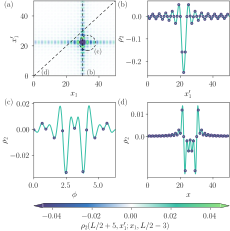

In [9]:
with mpl.rc_context({
    "figure.constrained_layout.use": False,
    "figure.autolayout": False,
    "savefig.bbox": None,
}):

    V = -0.5
    with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
        K = K_from_V(V)
    L = 50 

    x2 = L//2 - 3
    x4 = L-20
    reg = 1e-12
    n_points = 1000

    axs = []
    fig = plt.figure(figsize=[figsize[0],figsize[0]*1.1], constrained_layout=False)
    gs = fig.add_gridspec(5,3, height_ratios=[1,.3,1,.3,.055], width_ratios=[1,0.4,1])
    axs.append(ax_2RDM_color := fig.add_subplot(gs[0, 0]))
    axs.append(ax_slice1 := fig.add_subplot(gs[0, -1]))
    axs.append(ax_slice2 := fig.add_subplot(gs[2, 0]))
    axs.append(ax_slice3 := fig.add_subplot(gs[2, -1]))
    axs.append(ax_colorbar := fig.add_subplot(gs[-1, :]))


    # 1RDM fit
    fit_fun = lambda xi,ϵ : one_rdm(xp=xi, x=0.0, epsilon=ϵ, K=K, L=L, kF= np.pi / 2)

    obdm = load_obdm(L=L,V=V)[:,L//2]

    x = np.arange(-L//2,L//2)
    x_fine = np.linspace(-L/2,L/2+0.005,n_points)
    ϵ_fit = curve_fit(fit_fun,x,obdm,p0=0.84)[0][0]

    # 2RDM
    ax = axs[0]

    vmin, vmax = -0.045, 0.045
    X1,X3 = np.meshgrid(np.linspace(0,L,n_points),np.linspace(0,L,n_points))
    Z = np.real( two_rdm(x4, X3, x2, X1, epsilon=ϵ_fit, K=K, L=L, eta=0.0) )  
    im = ax.pcolormesh(X1, X3, np.real(Z), cmap=RDM_CMAP, vmin=vmin, vmax=vmax,rasterized=True)
    fig.colorbar(im, cax=ax_colorbar, orientation="horizontal",extend="both")

    ax_colorbar.set_xlabel(r"$\rho_2(L/2+5,x_1';x_1,L/2-3)$")
    ax_colorbar.set_xticks([-0.04, -0.02,0.0,0.02,0.04])

    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_1'$")

    ax.text(32.5,1,"(b)",fontsize=7)
    ax.text(37,15,"(c)",fontsize=7)
    ax.text(4.5,1,"(d)",fontsize=7)

    # Slice 1
    ax = axs[1]
    x1 = x4 
    x3 = np.linspace(0,L,n_points)
    full_TBDM = load_tbdm(L=L,V=V)
    ax.plot([full_TBDM[i,x4,x1,x2] for i in range(L)] ,'o',ms=2,zorder=10,color=COLORS[0],mfc="none")
    trdm = np.real( two_rdm(x4+reg, x3, x2, x1, epsilon=ϵ_fit, K=K, L=L, eta=0.0) )  
    ax.plot(x3, trdm,zorder=2,color=COLORS[3])
    ax.set_xlim(0,L)

    ax_2RDM_color.plot(np.zeros_like(x3)+x1,x3,"--", dashes=(5, 5),color="black",linewidth=0.5) 

    ax.set_xlabel("$x_1'$")
    ax.set_ylabel(r"$\rho_2$") # (30,22;x_2,30)

    # Slice 2 
    ax = axs[2] 
    r = 5
    center_x1 = x4 + 3
    center_x3 = x2
    x3 = np.concatenate([np.linspace(center_x3-r,center_x3+r,n_points)]) 
    x1 = np.concatenate([-np.sqrt(r**2-(x3-center_x3)**2) +center_x1,np.sqrt(r**2-(x3-center_x3)**2) +center_x1])
    x3 = np.concatenate([x3,x3])

    grid_points_on_circle = points_with_distance(center_x1,center_x3,r,range(L),range(L))
    gx_i, gx_j = zip(*grid_points_on_circle)
    gx_i, gx_j = np.array(gx_i), np.array(gx_j)

    _x = x1 - center_x1
    _y = x3 - center_x3
    phi = np.arccos(_x/np.sqrt(_x**2+_y**2))
    phi[_y<0] =  2*np.pi - phi[_y<0]

    _x = gx_i - center_x1
    _y = gx_j - center_x3
    phi_on_circle = np.arccos(_x/np.sqrt(_x**2+_y**2))
    phi_on_circle[_y<0] =  2*np.pi - phi_on_circle[_y<0]

    ax.plot(phi_on_circle,[full_TBDM[_x3,x4,x2,_x1] for _x1,_x3 in zip(gx_i, gx_j)] ,'o',ms=2,zorder=10,color=COLORS[0],mfc="none")

    inds = np.argsort(phi)
    trdm = np.real( two_rdm(x4, x3, x1, x2, epsilon=ϵ_fit, K=K, L=L, eta=0.0) )
    ax.plot(phi[inds],trdm[inds],zorder=2,color=COLORS[3])
    ax.set_xlim(0,2*np.pi)

    ax_2RDM_color.plot(x1[:len(x1)//2], x3[:len(x1)//2],"--", dashes=(4, 4),color="black",linewidth=0.5) 
    ax_2RDM_color.plot(x1[len(x1)//2:], x3[len(x1)//2:],"--", dashes=(4, 4) ,color="black",linewidth=0.5) 

    ax.set_xlabel("$\phi$")
    ax.set_ylabel(r"$\rho_2$") # (x_2'(\phi),22,x_2(\phi),30)
    ax.tick_params(axis='y', which='major', pad=0.5)

    # Slice 3   
    ax = axs[3]
    x3 = np.linspace(0,L,n_points)
    x1 = np.linspace(reg,L,n_points)
    ax.plot([full_TBDM[i,x4,x2,i] for i in range(L)] ,'o',ms=2,zorder=10,color=COLORS[0],mfc="none")
    trdm = np.real( two_rdm(x4, x3, x1, x2, epsilon=ϵ_fit, K=K, L=L, eta=0.0) )
    ax.plot(x3,trdm,zorder=2,color=COLORS[3])
    ax.set_xlim(0,L)

    ax_2RDM_color.plot(x1,x3,"--", dashes=(5, 5),color="black",linewidth=0.5)

    ax.set_xlabel("$x$")
    ax.set_ylabel(r"$\rho_2$") # (x,22,x,30)
    ax.set_yticks([0,0.01],["$0.0\phantom{.}$",r"$0.01$"])
    ax.tick_params(axis='y', which='major', pad=-0)

    # add subpanel labels
    for ax, lab, col in zip(axs[:-1],["(a)","(b)","(c)","(d)"],["black","black","black","black"]):
        ax.text(-0.3, 0.95 if lab in ["(a)","(b)"] else 1.0, lab,
            horizontalalignment='center',
            verticalalignment='center',
            transform = ax.transAxes,
            fontsize=8, color=col)

    fig.subplots_adjust(wspace=0, hspace=0.05)
    fig.savefig("../figures/Fig_11_2RDM_cuts.pdf", bbox_inches='tight')
    fig.savefig("../figures/Fig_11_2RDM_cuts.svg", bbox_inches='tight')

### Figure 12
Structure factor $s(q)$ and density-density correlations $g_2(r)$ (inset) for filling fractions $1/5$ (green diamonds) and $1/2$ (blue circles) obtained from DMRG simulations of the lattice model with size $L=50$ and $V/J=-1.0$. The dashed lines show the analytically obtained $q\to0$ limiting behavior, $s(q\to0)$, a linear function with slope $K/(2k_F)$. The solid lines depict the analytical result in very good agreement with the numerical data.

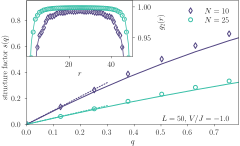

In [17]:
L = 50
V_OVER_J = -1.0
Q_LINEAR_MAX = 0.30

CASES = {
    10: {
        "K": 1.3413450915522336,
        "epsilon": 0.30536563404361927,
        "color": "#524582",
        "marker": "d",
    },
    25: {
        "K": 1.5000000000000000,
        "epsilon": 0.3731352585827924,
        "color": "#38bfa7",
        "marker": "o",
    },
}

RESULTS = {}

for N, case in CASES.items():
    rho0 = N / L
    kF = np.pi * rho0

    g2_data = load_g2(L, N, V_OVER_J)
    q_data, S_data = structure_factor(g2_data, rho0)

    r_lattice = np.arange(L, dtype=float)
    g2_analytic_raw = analytic_g2( r_lattice, epsilon=case["epsilon"], K=case["K"], L=L, rho0=rho0, kF=kF, )
    g2_analytic, trace_shift, trace_target = enforce_pair_sum_rule( g2_analytic_raw, rho0 )
    q_analytic, S_analytic = structure_factor(g2_analytic, rho0) 

    RESULTS[N] = {
        "rho0": rho0,
        "kF": kF,
        "g2_data": g2_data,
        "q_data": q_data,
        "S_data": S_data,
        "g2_analytic_raw": g2_analytic_raw,
        "g2_analytic": g2_analytic,
        "q_analytic": q_analytic,
        "S_analytic": S_analytic,
        "trace_shift": trace_shift,
    }

fig, ax = plt.subplots(layout="constrained")

for N, case in CASES.items():
    result = RESULTS[N]
    color = case["color"]
    marker = case["marker"]

    q_linear = np.linspace(0.0, Q_LINEAR_MAX, 301)
    ax.plot(q_linear,case["K"] * q_linear / (2.0 * result["kF"]),linestyle=":",linewidth=1.0,color=color)
    ax.plot(result["q_data"],result["S_data"].real,marker=marker,linestyle="none",label=rf"$N={N}$",**marker_style(color))
    ax.plot(result["q_analytic"],result["S_analytic"].real,linestyle="-",color=color,zorder=-10)

ax.set_xlabel(r"$q$")
ax.set_ylabel(r"structure factor $s(q)$")
ax.set_xlim(0.0, 0.79)
ax.set_ylim(0.0, 0.95)
ax.text(0.78,0.01,rf"$L={L},\,V/J={V_OVER_J:.1f}$",ha="right",va="bottom")
ax.legend(loc="upper right")

# Real-space pair distribution inset.
inset = inset_axes(ax,width="50%",height="45%",loc="upper left",borderpad=0,axes_kwargs={"facecolor": "white"})
r_dense = np.linspace(0.0, L, 10000)

for N, case in CASES.items():
    result = RESULTS[N]
    color = case["color"]
    marker = case["marker"]

    inset.plot(np.arange(L),result["g2_data"],marker=marker,linestyle="none",**marker_style(color))
    line, = inset.plot(r_dense,analytic_g2(r_dense,epsilon=case["epsilon"],K=case["K"],L=L,
                                   rho0=result["rho0"],kF=result["kF"]),color=color, lw=0.75)
    line.set_path_effects([pe.Stroke(linewidth=0.95, foreground='white'),pe.Normal(),])

inset.set_xlabel(r"$r$")
inset.set_xlim(0.001, L - 0.001)
inset.set_ylim(0.92, 1.01)
inset.set_yticks([0.95, 1.00])
inset.yaxis.tick_right()
inset.yaxis.set_label_position("right")
inset.set_ylabel(r"$g_2(r)$")
inset.yaxis.set_label_coords(1.23, 0.64) 

fig.savefig("../figures/Fig_12_structure_factor_q_shifttrace.pdf")
fig.savefig("../figures/Fig_12_structure_factor_q_shifttrace.svg") 


### Figure 13
The two body ground state energy $E_0$ divided by the hopping parameter $J$ as a function of the Luttinger parameter $K$ for different system sizes. Solid lines show the analytic result while dark blue circles are the numerical results from DMRG. The righthand panel shows the energy density per particle. Strong agreement is shown for values of $K$ below 1.5.

In [18]:
def get_ϵ(V,L,folder):
    """Get the ϵ parameter by a fit to the 1-RDM data."""
    K = K_from_V(V)
    fit_fun = lambda xi,ϵ : one_rdm(xp=xi, x=0.0, epsilon=ϵ, K=K, L=L, kF= np.pi / 2) 
    obdm = load_obdm(L=L,V=V,folder=folder)[:,L//2] 
    x = np.arange(-L//2,L//2) 
    ϵ_fit = curve_fit(fit_fun,x,obdm,p0=0.84)[0][0] 
    return ϵ_fit

In [19]:
vs = np.array([-1.44104,-1.41421,-1.41000,-1.38545,-1.36000,-1.35456,-1.32135,-1.31000,-1.28558,-1.26000,-1.24698,-1.21000,-1.20527,-1.16011,-1.16000,-1.11114,-1.11000,-1.06000,-1.05793,-1.01000,-1.00000,-1.00000,-0.96000,-0.93682,-0.91000,-0.86777,-0.86000,-0.81000,-0.79216,-0.76000,-0.71000,-0.70921,-0.66000,-0.61803,-0.61000,-0.56000,-0.51764,-0.51000,-0.46000,-0.41000,-0.40691,-0.36000,-0.31000,-0.28463,-0.26000,-0.21000,-0.16000,-0.14946,-0.11000,-0.06000,-0.01000,0.00000,0.04000,0.09000,0.14000,0.16516,0.19000,0.24000,0.29000,0.34000,0.34730,0.39000,0.44000,0.44504,0.49000,0.54000,0.54733,0.59000,0.64000,0.69000,0.74000,0.76537,0.79000,0.84000,0.89000,0.94000,0.99000,1.00000,1.00000,1.04000,1.09000,1.14000,1.19000,1.24000,1.24698,1.29000,1.34000,1.39000,1.41421,1.44000,1.49000,1.49702 ,1.54000,1.59000,1.64000,1.69000,1.73205,1.74000,1.79000,1.84000,1.87939,1.89000,1.91899,1.94000,1.99000,2.00000])

/var/folders/7h/n8nd5yq95679t4llv_wkmc3m0000gn/T/ipykernel_4170/2405006170.py:7: OptimizeWarning: Covariance of the parameters could not be estimated
  ϵ_fit = curve_fit(fit_fun,x,obdm,p0=0.84)[0][0]


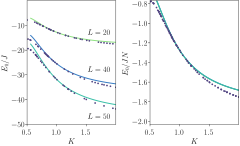

In [20]:
# Energies
fig, axs_top = plt.subplots(1, 2)

ax=axs_top[0]

with np.errstate(divide="ignore", invalid="ignore", over="ignore"):  
 
       data_path_L20 = Path("../data/dmrg/energy/L20_M10/")
       V20, E20 = load_energies(data_path_L20)
       K20 = K_from_V(V20)
       data_path_L40 = Path("../data/dmrg/energy/L40_M20/")
       V40, E40 = load_energies(data_path_L40)
       K40 = K_from_V(V40)
       data_path_L50 = Path("../data/dmrg/energy/L50_M25/")
       V50, E50 = load_energies(data_path_L50)
       K50 = K_from_V(V50) 

cols = [COLORS[4],COLORS[1], COLORS[3]]
for _L, c in zip([20,40,50],cols): 
       folder = Path(f"../data/dmrg/obdm/L{_L}_M{_L//2}/") 
       ax.plot(K_from_V(vs[:-4]),[E_sum(get_ϵ(v,_L,folder), v, _L) for v in vs[:-4]],color=c,zorder=2,ls="-",marker="none") 
ax.set_xlim(.5,2) 

ax.plot(K20[::3], E20[::3], 'o', ms=.8,linewidth=0.3,label="$L=20$", color=COLORS[0])
ax.plot(K40[::3], E40[::3], 'o', ms=.8,linewidth=0.3,label="$L=40$", color=COLORS[0])
ax.plot(K50[::3], E50[::3], 'o', ms=.8,linewidth=0.3, label="$L=50$", color=COLORS[0])
ax.set_xlabel("$K$")
ax.set_ylabel("$E_0/J$")
ax.set_ylim(-50,-.000001)
ax.text(1.95,-13,"$L=20$", fontsize=8, horizontalalignment="right",verticalalignment="center")
ax.text(1.95,-28,"$L=40$", fontsize=8, horizontalalignment="right",verticalalignment="center")
ax.text(1.95,-47,"$L=50$", fontsize=8, horizontalalignment="right",verticalalignment="center")
ax.tick_params(axis='y', which='major', pad=-1)
ax.set_xlim(.5,1.999999)
ax=axs_top[1]
for _L, c in zip([20,40,50],cols): 
       folder = Path(f"../data/dmrg/obdm/L{_L}_M{_L//2}/")
       ax.plot(K_from_V(vs[:-4]),[E_sum(get_ϵ(v,_L,folder), v, _L) / (_L//2) for v in vs[:-4]],color=c,zorder=2,ls="-",marker="none") 
 
ax.set_xlim(.5,1.99999)

ax.plot(K20[::3], E20[::3]/10, 'o', ms=.8,linewidth=0.3,label="$L=20$", color=COLORS[0])
ax.plot(K40[::3], E40[::3]/20, 'o', ms=.8,linewidth=0.3,label="$L=40$", color=COLORS[0])
ax.plot(K50[::3], E50[::3]/25, 'o', ms=.8,linewidth=0.3, label="$L=50$", color=COLORS[0])
ax.set_xlabel("$K$")
ax.set_ylabel("$E_0/JN$")
ax.set_ylim(-2.03,-0.77)
ax.tick_params(axis='y', which='major', pad=-1)
 
plt.show()

fig.savefig("../figures/Fig_13_DMRG_Energies.pdf")
fig.savefig("../figures/Fig_13_DMRG_Energies.svg")

### Bonus Figure: Spherical Heatmap

The 2-RDM $\rho_2(x_2',x_1';x_1,x_2)$ plotted on the surface of a sphere where we have fixed $\Delta R^2 + {r^2}/{2}+{{r'}^2}/{2}=144$, $L=40$, $K=8/5$ (attractive), $n_0=1/2$, and $\epsilon=1$ (see Section IV for parameter details). The colormap corresponds to a range from $-0.03$ (blue) to $0.03$ (green). Alternating blue-green regions signal the sign change from fermion antisymmetry, while the vanishing of $\rho_2$ along $r=0,r'=0$ is due to the Pauli exclusion principle.

In [24]:
from matplotlib.colors import TwoSlopeNorm

# Physical and plotting parameters.
L = 40.0
EPSILON = 1.0
K = 8 / 5
C = 144.0

# Spherical grid resolution. Increase to, e.g., 600 x 360 for a final
# one-off render if your local machine can tolerate a slower save.
N_THETA = 2*420
N_PHI = 2*252

# Diverging colormap centered at zero. The palette keeps the purple/green
# visual character of the original notebook but is static-export friendly.
RDM_CMAP = LinearSegmentedColormap.from_list(
    "rdm_purple_white_green",
    ["#524582", "#367bc3", "#FFFFFF", "#38bfa7", "#8fe182"],
    N=512,
)

def make_sphere_grid(C_value, n_theta=N_THETA, n_phi=N_PHI):
    r"""Return a closed grid in physical coordinates (r, r', Delta R).

    The sampled shell obeys

        Delta R**2 + r**2/2 + r'**2/2 = C.

    The azimuthal seam is closed by duplicating the first column after the
    field has been evaluated on a cell-centered angular grid.
    """
    radius = np.sqrt(C_value)
    pi = np.pi

    # Cell-centered theta and phi avoid exact polar points and exact r=0 or
    # r'=0 coincidence lines while still covering the full shell uniformly.
    theta = (np.arange(n_theta) + 0.5) * 2.0 * pi / n_theta
    phi = (np.arange(n_phi) + 0.5) * pi / n_phi
    theta, phi = np.meshgrid(theta, phi, indexing="xy")

    r = np.sqrt(2.0) * radius * np.sin(phi) * np.cos(theta)
    rp = np.sqrt(2.0) * radius * np.sin(phi) * np.sin(theta)
    delta_R = radius * np.cos(phi)

    # Close the azimuthal seam for plot_surface.
    r = np.concatenate([r, r[:, :1]], axis=1)
    rp = np.concatenate([rp, rp[:, :1]], axis=1)
    delta_R = np.concatenate([delta_R, delta_R[:, :1]], axis=1)

    return r, rp, delta_R

def compute_spherical_heatmap(C_value=C, epsilon=EPSILON, K_value=K, L_value=L):
    """Evaluate the interaction correction on the physical-coordinate shell."""
    X, Y, Z = make_sphere_grid(C_value)

    values = two_rdm_fixed_delta_R(X,Y,Z,epsilon,K_value,L_value,eta=0.0,)
    return X, Y, Z, values

X, Y, Z, complex_values = compute_spherical_heatmap(C, EPSILON, K, L)
values = np.real(complex_values)

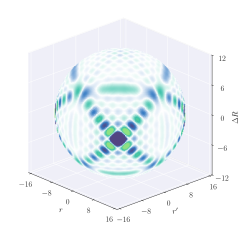

In [25]:
def _symmetric_ticks(limit, step):
    """Return symmetric ticks from -limit to +limit using a readable step."""
    max_tick = step * np.floor(limit / step)
    ticks = np.arange(-max_tick, max_tick + 0.5 * step, step)
    return ticks

def plot_spherical_heatmap(X,Y,Z,values,*,C_value=C,K_value=K,L_value=L,
                           epsilon=EPSILON,cmap=RDM_CMAP,color_limit=None,show_title=False,):
    finite_values = values[np.isfinite(values)]
    
    if finite_values.size == 0:
        raise ValueError("No finite values are available for plotting.")

    if color_limit is None:
        color_limit = np.nanmax(np.abs(finite_values))

    norm = TwoSlopeNorm(vmin=-color_limit,vcenter=0.0,vmax=color_limit,)

    r_limit = np.sqrt(2.0 * C_value)
    delta_limit = np.sqrt(C_value)

    fig = plt.figure(figsize=(figsize[0],figsize[0]), constrained_layout=True)
    ax = fig.add_subplot(111, projection="3d")

    # Orthographic projection removes perspective distortion and is usually
    # preferable for a static figure panel.
    try:
        ax.set_proj_type("ortho")
    except AttributeError:
        pass

    surface = ax.plot_surface(X,Y,Z,facecolors=cmap(norm(values)),rstride=1,cstride=1,linewidth=0,
                              antialiased=False,shade=False,)

    # Rasterizing the surface keeps the PDF compact while preserving vector
    # text, ticks, axes, and colorbar.
    surface.set_rasterized(True)

    ax.set_xlim(-r_limit, r_limit)
    ax.set_ylim(-r_limit, r_limit)
    ax.set_zlim(-delta_limit, delta_limit)

    # Use true data-scale aspect: r and r' span sqrt(2) times the Delta-R span.
    ax.set_box_aspect((2.0 * r_limit, 2.0 * r_limit, 2.0 * delta_limit * np.sqrt(2.0)), zoom=0.94)

    ax.set_xticks(_symmetric_ticks(r_limit, 8.0))
    ax.set_yticks(_symmetric_ticks(r_limit, 8.0))
    ax.set_zticks(_symmetric_ticks(delta_limit, 6.0))

    ax.set_xlabel(r"$r$", labelpad=-6)
    ax.set_ylabel(r"$r'$", labelpad=-6)
    #ax.set_zlabel("$\Delta R$", labelpad=-8)
    ax.text2D(1.01,0.50,r"$\Delta R$",transform=ax.transAxes,rotation=90,rotation_mode="anchor",ha="center",va="center")

    # Camera angle chosen so that all three physical axes and the projected
    # pane grid are visible without crowding the labels.
    ax.view_init(elev=23, azim=-43)
    ax.tick_params(axis='x', pad=-2)
    ax.tick_params(axis='y', pad=-2)
    ax.tick_params(axis='z', pad=-1)

    # Pane and grid styling.  Matplotlib's 3D grid is the projected axis grid.
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_facecolor((0.88, 0.88, 0.95, 1.0))
        axis._axinfo["grid"].update({
            "color": (1, 1, 1, 1.0),
            "linewidth": 0.45,
            "linestyle": "-",
        })
        axis._axinfo["axisline"].update({
            "linewidth": 0.8,
            "color": (0.0, 0.0, 0.0, 1.0),
        })

    ax.grid(True)

    if show_title:
        ax.set_title(
            rf"$K={K_value:g},\; L={L_value:g},\; \epsilon={epsilon:g}$",
            pad=4,
        )

    return fig, ax


fig, ax = plot_spherical_heatmap(X, Y, Z, values,color_limit=0.03)
fig.savefig("../figures/spherical_heatmap.pdf")
fig.savefig("../figures/spherical_heatmap.png")